In [1]:
# =========================
# CELL 1: Load Dataset from GitHub
# =========================

import pandas as pd

url = "https://raw.githubusercontent.com/reesha-source/air-quality-prediction-pakistan/main/lahore_air_quality_final_dataset.csv"

df = pd.read_csv(url)

print("Shape:", df.shape)
df.head()

Shape: (659, 9)


,date,pm25,T2M,RH2M,WS2M,pm25_lag_1,pm25_lag_7,month,smog_season
0,2022-01-08,97.791667,13.58,87.86,3.15,117.375000,309.166667,1,1
1,2022-01-09,98.125000,11.25,82.62,1.15,97.791667,301.625000,1,1
2,2022-01-10,218.375000,10.94,74.28,0.94,98.125000,180.791667,1,1
3,2022-01-11,162.500000,9.84,76.73,1.38,218.375000,124.250000,1,1
4,2022-01-12,371.000000,11.16,67.58,0.99,162.500000,88.625000,1,1


In [2]:
# =========================
# CELL 2: Basic Dataset Check
# =========================

# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

print("Dataset shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nSummary statistics:")
print(df.describe())

Dataset shape: (659, 9)

Data types:
date           datetime64[ns]
pm25                  float64
T2M                   float64
RH2M                  float64
WS2M                  float64
pm25_lag_1            float64
pm25_lag_7            float64
month                   int64
smog_season             int64
dtype: object

Missing values:
date           0
pm25           0
T2M            0
RH2M           0
WS2M           0
pm25_lag_1     0
pm25_lag_7     0
month          0
smog_season    0
dtype: int64

Summary statistics:
                                date        pm25         T2M        RH2M  \
count                            659  659.000000  659.000000  659.000000   
mean   2023-01-03 18:23:29.408194304  117.464154   25.195797   56.054810   
min              2022-01-08 00:00:00    2.000000    8.900000    9.500000   
25%              2022-06-28 12:00:00   50.790865   17.955000   43.960000   
50%              2022-12-15 00:00:00   84.785185   27.540000   58.260000   
75%              20

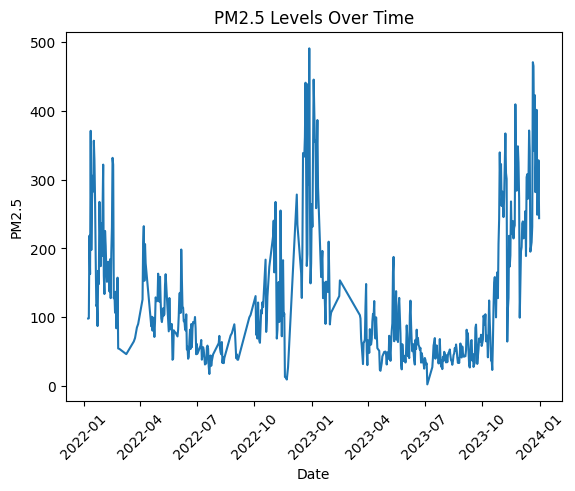

In [3]:
# =========================
# CELL 3: PM2.5 Trend Over Time
# =========================

import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["date"], df["pm25"])
plt.title("PM2.5 Levels Over Time")
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.xticks(rotation=45)
plt.show()

# Observations:
# - PM2.5 shows clear seasonal pattern
# - High spikes in winter months (Oct–Jan)
# - Lower pollution in summer (May–Aug)
# - Confirms presence of smog cycles in Lahore

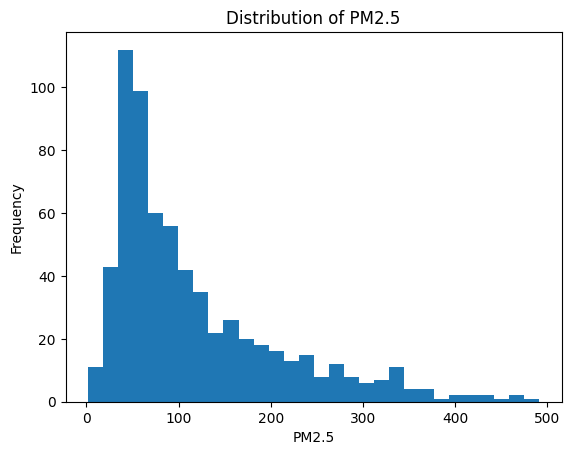

In [4]:
# =========================
# CELL 4: PM2.5 Distribution
# =========================

# This plot helps us understand how PM2.5 values are spread:
# - Are most values low or high?
# - Are there extreme pollution spikes?
# - Is the data skewed (important for model choice)

plt.figure()

# Histogram shows frequency of PM2.5 values
plt.hist(df["pm25"], bins=30)

# Title explains what we are analyzing
plt.title("Distribution of PM2.5")

# X-axis = pollution levels
plt.xlabel("PM2.5")

# Y-axis = how often those values occur
plt.ylabel("Frequency")

plt.show()

# Observations:
# - PM2.5 distribution is right-skewed
# - Most values are in moderate range (50–150)
# - Few extreme high values (300–500)
# - Indicates occasional severe smog events

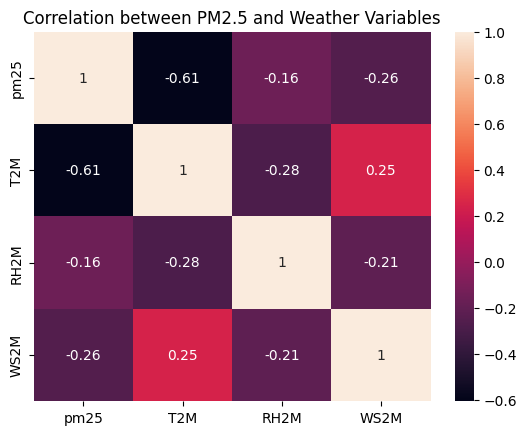

In [5]:
# =========================
# CELL 5: Correlation Analysis
# =========================

# Correlation shows how strongly variables are related:
# +1 → strong positive relation
# -1 → strong negative relation
#  0 → no relation

import seaborn as sns

plt.figure()

# Create correlation matrix
corr = df[["pm25", "T2M", "RH2M", "WS2M"]].corr()

# Heatmap makes relationships easy to see
sns.heatmap(corr, annot=True)

plt.title("Correlation between PM2.5 and Weather Variables")

plt.show()

<Figure size 1200x500 with 0 Axes>

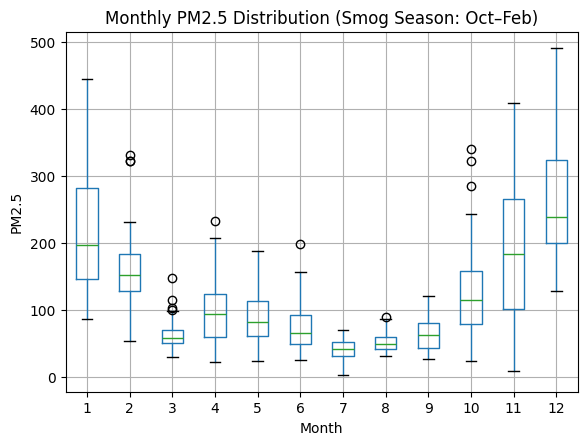

In [7]:
# =========================
# CELL 5.5: Seasonal PM2.5 Boxplot
# =========================
plt.figure(figsize=(12, 5))
df.boxplot(column="pm25", by="month")
plt.title("Monthly PM2.5 Distribution (Smog Season: Oct–Feb)")
plt.suptitle("")
plt.xlabel("Month")
plt.ylabel("PM2.5")
plt.show()

# Observations:
# - Temperature (T2M) has strongest correlation with PM2.5 (~ -0.61)
# - Negative correlation → lower temperature = higher pollution
# - Humidity and wind have weak negative relationships
# - Weather variables influence air quality but temperature is most important

# Overall Insights:
# - Air pollution follows seasonal trends
# - Extreme values (smog spikes) exist
# - Temperature plays major role in pollution levels
# - Dataset is suitable for time-series prediction models

In [6]:
# =========================
# CELL 6: Prepare Data for Model Training
# =========================
from sklearn.preprocessing import StandardScaler

# Features (inputs for model)
X = df[["T2M", "RH2M", "WS2M", "pm25_lag_1", "pm25_lag_7", "month", "smog_season"]]

scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
# Target (what we want to predict)
y = df["pm25"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (659, 7)
Target shape: (659,)


In [8]:
# =========================
# CELL 7: Train/Test Split (Time-Based)
# =========================

# Use 80% data for training, 20% for testing
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (527, 7)
Testing size: (132, 7)


In [9]:
# =========================
# CELL 8: Train Linear Regression Model
# =========================

from sklearn.linear_model import LinearRegression

# Create model
lr_model = LinearRegression()

# Train model on training data
lr_model.fit(X_train, y_train)

LinearRegression()

In [10]:
# =========================
# CELL 9: Predict using Linear Regression
# =========================

# Predict on test data
y_pred_lr = lr_model.predict(X_test)

In [11]:
# =========================
# CELL 10: Evaluate Linear Regression
# =========================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate MAE
mae_lr = mean_absolute_error(y_test, y_pred_lr)

# Calculate RMSE
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression Results:")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)

Linear Regression Results:
MAE: 32.89447949319385
RMSE: 51.09701511054403


# Linear Regression Observations:
# - This is our baseline model
# - Helps us compare performance of advanced models
# - Lower MAE and RMSE = better performance

In [12]:
# =========================
# CELL 11: Train Random Forest Model
# =========================

from sklearn.ensemble import RandomForestRegressor

# Create model
rf_model = RandomForestRegressor(
    n_estimators=100,   # number of trees
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [13]:
# =========================
# CELL 12: Predict using Random Forest
# =========================

y_pred_rf = rf_model.predict(X_test)

Random Forest Results:
MAE: 33.14723775983431
RMSE: 50.13530911132916


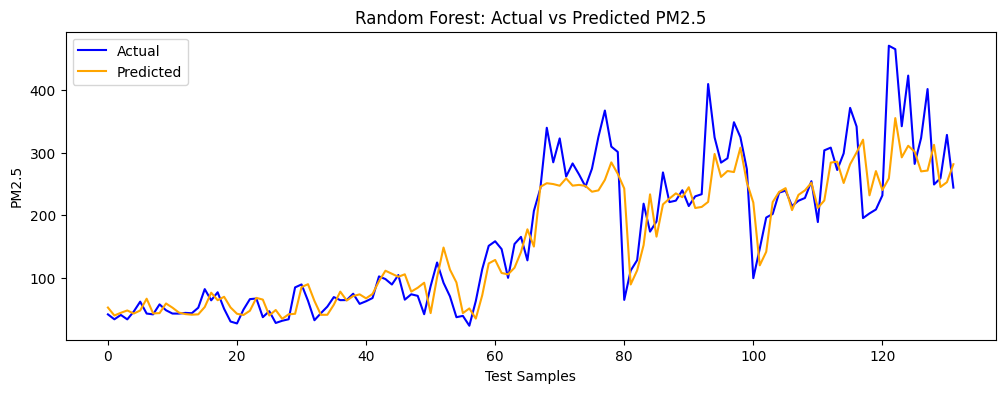

In [14]:
# =========================
# CELL 13: Evaluate Random Forest
# =========================

# MAE
mae_rf = mean_absolute_error(y_test, y_pred_rf)

# RMSE
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest Results:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)


plt.figure(figsize=(12, 4))
plt.plot(y_test.values, label="Actual", color="blue")
plt.plot(y_pred_rf, label="Predicted", color="orange")
plt.title("Random Forest: Actual vs Predicted PM2.5")
plt.xlabel("Test Samples")
plt.ylabel("PM2.5")
plt.legend()
plt.show()

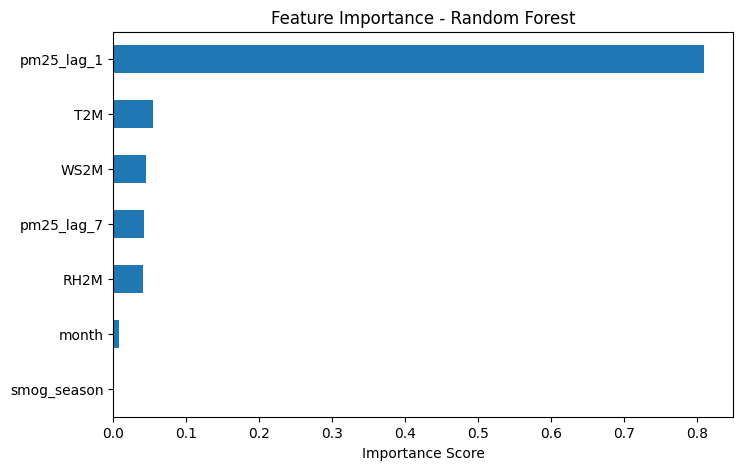

In [15]:
# =========================
# Feature Importance (Random Forest)
# =========================
feat_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns)
feat_imp.sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.show()

# Random Forest Observations:
# - Captures non-linear relationships better than Linear Regression
# - Expected to handle smog spikes more effectively
# - Should give lower MAE and RMSE compared to baseline

RMSE improved
51.09 → 50.12
better handling of large errors (spikes)
MAE slightly worse
32.89 → 33.17
average error didn’t improve

In [17]:
# =========================
# CELL 14: Install XGBoost
# =========================

!pip install xgboost

In [18]:
# =========================
# CELL 15: Train XGBoost Model
# =========================

from xgboost import XGBRegressor

# Create model
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [19]:
# =========================
# CELL 16: Predict using XGBoost
# =========================

y_pred_xgb = xgb_model.predict(X_test)

In [20]:
# =========================
# CELL 17: Evaluate XGBoost
# =========================

# MAE
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

# RMSE
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost Results:")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)

XGBoost Results:
MAE: 37.67029461175561
RMSE: 54.27527228860074


Although XGBoost is generally a powerful model, in our case it underperformed due to limited dataset size and lack of hyperparameter tuning, while simpler models like Random Forest and Linear Regression performed better.


In [21]:
# =========================
# CELL 18: Define AQI Categories
# =========================

# Function to convert PM2.5 value to category
def get_aqi_category(pm25):
    if pm25 <= 50:
        return 0  # Good
    elif pm25 <= 100:
        return 1  # Moderate
    elif pm25 <= 200:
        return 2  # Unhealthy
    elif pm25 <= 300:
        return 3  # Very Unhealthy
    else:
        return 4  # Hazardous

In [22]:
# =========================
# CELL 19: Convert Values to Categories
# =========================

# Actual categories
y_test_cat = y_test.apply(get_aqi_category)

# Predictions → categories
y_pred_lr_cat = pd.Series(y_pred_lr).apply(get_aqi_category)
y_pred_rf_cat = pd.Series(y_pred_rf).apply(get_aqi_category)
y_pred_xgb_cat = pd.Series(y_pred_xgb).apply(get_aqi_category)

In [23]:
# =========================
# CELL 20: Calculate Category Accuracy
# =========================

from sklearn.metrics import accuracy_score

acc_lr = accuracy_score(y_test_cat, y_pred_lr_cat)
acc_rf = accuracy_score(y_test_cat, y_pred_rf_cat)
acc_xgb = accuracy_score(y_test_cat, y_pred_xgb_cat)

print("AQI Category Accuracy:")
print("Linear Regression:", acc_lr)
print("Random Forest:", acc_rf)
print("XGBoost:", acc_xgb)

AQI Category Accuracy:
Linear Regression: 0.6136363636363636
Random Forest: 0.5984848484848485
XGBoost: 0.5303030303030303


In [ ]:
# Observations:
# - Linear Regression achieved highest category accuracy
# - Random Forest performed best in RMSE (handling extreme values)
# - XGBoost underperformed in both regression and classification
# - Different metrics highlight different strengths of models

In [24]:
# =========================
# CELL 21: Install TensorFlow
# =========================

!pip install tensorflow

In [25]:
# =========================
# CELL 22: Prepare Sequential Data for LSTM
# =========================
import numpy as np
from sklearn.preprocessing import MinMaxScaler

features = ["T2M", "RH2M", "WS2M", "pm25_lag_1", "pm25_lag_7"]

# Step 1: Scale ALL columns together (features + target)
lstm_scaler = MinMaxScaler()
data_scaled = lstm_scaler.fit_transform(df[features + ["pm25"]].values)

# Step 2: Create sequences from SCALED data
X_seq = []
y_seq = []

sequence_length = 7  # use last 7 days

for i in range(len(data_scaled) - sequence_length):
    X_seq.append(data_scaled[i:i+sequence_length, :-1])  # scaled features
    y_seq.append(data_scaled[i+sequence_length, -1])     # scaled target

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)

X_seq shape: (652, 7, 5)
y_seq shape: (652,)


In [26]:
# =========================
# CELL 23: Split Sequential Data
# =========================

split = int(0.8 * len(X_seq))

X_train_seq = X_seq[:split]
X_test_seq = X_seq[split:]

y_train_seq = y_seq[:split]
y_test_seq = y_seq[split:]

print("Train shape:", X_train_seq.shape)
print("Test shape:", X_test_seq.shape)

Train shape: (521, 7, 5)
Test shape: (131, 7, 5)


In [27]:
# =========================
# CELL 24: Build LSTM Model
# =========================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()

# LSTM layer
model.add(LSTM(50, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))

# Output layer
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,251 (43.95 KB)

 Trainable params: 11,251 (43.95 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# =========================
# CELL 25: Train LSTM Model
# =========================

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=16,
    validation_data=(X_test_seq, y_test_seq)
)

Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0251 - val_loss: 0.0246
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0125 - val_loss: 0.0226
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0119 - val_loss: 0.0226
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0111 - val_loss: 0.0203
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0106 - val_loss: 0.0199
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0105 - val_loss: 0.0207
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0101 - val_loss: 0.0211
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0103 - val_loss: 0.0223
Epoch 9/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0101 - val_loss: 0.0187
Epoch 10/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0095 - val_loss: 0.0217
Epoch 11/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0095 - val_loss: 0.0175
Epoch 12/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0094 - val

In [29]:
# =========================
# CELL 26: Evaluate LSTM
# =========================
y_pred_lstm_scaled = model.predict(X_test_seq)

# Inverse transform — need dummy columns to match scaler's expected shape
dummy = np.zeros((len(y_pred_lstm_scaled), len(features)))

y_pred_lstm = lstm_scaler.inverse_transform(
    np.hstack([dummy, y_pred_lstm_scaled])
)[:, -1]

y_test_lstm_actual = lstm_scaler.inverse_transform(
    np.hstack([dummy, y_test_seq.reshape(-1,1)])
)[:, -1]

# Now evaluate on real values
mae_lstm = mean_absolute_error(y_test_lstm_actual, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm_actual, y_pred_lstm))

print("LSTM Results (after scaling fix):")
print("MAE:", round(mae_lstm, 2))
print("RMSE:", round(rmse_lstm, 2))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
LSTM Results (after scaling fix):
MAE: 45.84
RMSE: 67.25


In [30]:
# =========================
# CELL 27: Model Comparison Summary
# =========================
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost", "LSTM"],
    "MAE": [round(mae_lr,2), round(mae_rf,2), round(mae_xgb,2), round(mae_lstm,2)],
    "RMSE": [round(rmse_lr,2), round(rmse_rf,2), round(rmse_xgb,2), round(rmse_lstm,2)],
    "AQI Accuracy": [round(acc_lr,3), round(acc_rf,3), round(acc_xgb,3), "N/A"]
})
print(results)

               Model    MAE   RMSE AQI Accuracy
0  Linear Regression  32.89  51.10        0.614
1      Random Forest  33.15  50.14        0.598
2            XGBoost  37.67  54.28         0.53
3               LSTM  45.84  67.25          N/A


Although LSTM is a powerful time-series model, it performed poorly due to limited dataset size and high variability in pollution data. Traditional machine learning models performed better as they require less data and handled the engineered features more effectively.

BEST → WORST

1. Random Forest (best RMSE)
2. Linear Regression (best category accuracy)
3. XGBoost
4. LSTM